# Importação de bibliotecas

In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E PACOTES
# ==============================================================================
# 1. Bibliotecas de terceiros (manipulação de dados e visualização)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Importação de dados

In [2]:
# ==============================================================================
# 2. CONFIGURAÇÃO DE CAMINHOS (PATHS) E PARÂMETROS GERAIS
# ==============================================================================
# 1. Caminhos de diretório base
PATH_RAW = '../data/raw'
PATH_PROCESSED = '../data/processed'
PATH_SIMILARITY_MATRICES = f'{PATH_PROCESSED}/similarity_matrices'

# 2. Caminhos de arquivos de entrada (Inputs)
PATH_ADJACENCY = f'{PATH_RAW}/adjacency_matrices/0_adj_consolidated_2016-2025.txt'
PATH_NAMES = f'{PATH_RAW}/researchers_names.txt'

# 3. Caminhos de arquivos de saída (Outputs)
OUTPUT_LABELED_MATRIX_PARQUET = f'{PATH_PROCESSED}/pre_existing_labeled.parquet'
OUTPUT_FILTERED_MATRIX_PARQUET = f'{PATH_SIMILARITY_MATRICES}/suggestions_filtered.parquet'
# OUTPUT_LABELED_MATRIX_CSV = f'{PATH_PROCESSED}/pre_existing_labeled.csv'
# OUTPUT_FILTERED_MATRIX_CSV = f'{PATH_SIMILARITY_MATRICES}/suggestions_filtered.csv'

# 4. Dicionário de cenários de similaridade processados
SCENARIOS = {
    'unigram' : f'{PATH_SIMILARITY_MATRICES}/similarity_unigram.parquet',
    'bigram' : f'{PATH_SIMILARITY_MATRICES}/similarity_bigram.parquet',
    'mixed' : f'{PATH_SIMILARITY_MATRICES}/similarity_mixed.parquet'
}

# 5. Dicionário de tradução para gráficos e tabelas
SCENARIO_LABELS = {
    'unigram': 'Unigrama',
    'bigram': 'Bigrama',
    'mixed': 'Misto'
}

In [3]:
# ==============================================================================
# 3. CARREGAMENTO DOS DADOS (LOAD)
# ==============================================================================
print(">>> Iniciando carregamento dos dados...")

# 1. Carrega a matriz de adjacência (colaborações) e a lista de nomes
matrix_adj = pd.read_table(PATH_ADJACENCY, sep=' ', header=None)
names_total = pd.read_table(PATH_NAMES, header=None)

# 2. Carrega as matrizes de similaridade por cenário (n-gramas)
dfs = {}
for name, path in SCENARIOS.items():
    dfs[name] = pd.read_parquet(path)
    dfs[name].index.name = None
    dfs[name].index = dfs[name].columns

print("✅ Carregamento concluído!\n")
print(f"Dimensões da matriz de similaridade - unigrama: {dfs['unigram'].shape}")
dfs['unigram']

>>> Iniciando carregamento dos dados...
✅ Carregamento concluído!

Dimensões da matriz de similaridade - unigrama: (89, 89)


,Adriano Jose Ferruzzi,Alessandra da Silva Carneiro,Alessandro Emilio Teruzzi,Alex Sandro Rodrigues Ancioto,Alexandre José Romagnoli,Alexandre Machado Rosa,Ana Carolina Vila Ramos dos Santos,Ana Claudia Folha da Cruz,Ana Márcia Lima Costa,Ana Paula Rodrigues Magalhães de Barros,...,Silene Jucelino de Lima,Tatiana Aparecida Picosque,Teresa Helena Buscato Martins,Thiago Pedro Donadon Homem,Thiago Silva Broze,Valdir Donizete dos Santos Junior,Vanessa Regina Ferreira da Silva,Whisner Fraga Mamede,Wilian Ramalho Feitosa,William Rosseti
Adriano Jose Ferruzzi,1.000000,0.0,0.000000,0.036120,0.047782,0.000000,0.026851,0.056773,0.000000,0.008676,...,0.000000,0.028387,0.064923,0.027418,0.033787,0.014517,0.000000,0.0,0.063665,0.022630
Alessandra da Silva Carneiro,0.000000,1.0,0.000000,0.000000,0.000000,0.052705,0.015610,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Alessandro Emilio Teruzzi,0.000000,0.0,1.000000,0.048795,0.032275,0.000000,0.000000,0.000000,0.163299,0.117202,...,0.000000,0.000000,0.043853,0.000000,0.000000,0.039223,0.000000,0.0,0.009556,0.030571
Alex Sandro Rodrigues Ancioto,0.036120,0.0,0.048795,1.000000,0.031497,0.000000,0.000000,0.037424,0.039841,0.057189,...,0.000000,0.000000,0.064194,0.036147,0.000000,0.000000,0.000000,0.0,0.018652,0.014917
Alexandre José Romagnoli,0.047782,0.0,0.032275,0.031497,1.000000,0.052705,0.039024,0.049507,0.026352,0.007565,...,0.000000,0.024754,0.070767,0.000000,0.036828,0.012659,0.000000,0.0,0.101782,0.078934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valdir Donizete dos Santos Junior,0.014517,0.0,0.039223,0.000000,0.012659,0.032026,0.000000,0.000000,0.000000,0.027582,...,0.000000,0.000000,0.017201,0.019371,0.000000,1.000000,0.000000,0.0,0.003748,0.035973
Vanessa Regina Ferreira da Silva,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110096,0.173838,...,0.000000,0.000000,0.000000,0.000000,0.015386,0.000000,1.000000,0.0,0.019329,0.041222
Whisner Fraga Mamede,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.029463,0.000000,0.000000,1.0,0.000000,0.000000
Wilian Ramalho Feitosa,0.063665,0.0,0.009556,0.018652,0.101782,0.046816,0.048530,0.014659,0.015605,0.022400,...,0.258022,0.029318,0.037717,0.089672,0.161389,0.003748,0.019329,0.0,1.000000,0.300911


# Tratamento de dados

In [4]:
# ==============================================================================
# 4. TRATAMENTO, LIMPEZA E ENRIQUECIMENTO DOS DADOS
# ==============================================================================
print(">>> Iniciando tratamento e enriquecimento dos dados...")

# 1. Extração de Metadados
# Converte a série de nomes em lista para indexação
list_names = names_total[0].tolist()
print(f'Total de pesquisadores mapeados: {len(list_names)}')

# 2. Limpeza de artefatos (Data Cleaning)
# Remove coluna residual (índice 169) que contém apenas NaN da extração original
matrix_cleaned = matrix_adj.drop(columns=[169])

# 3. Enriquecimento (Labeling)
# Associa os nomes dos pesquisadores à matriz numérica (que originalmente não tinha cabeçalho)
df_names = pd.DataFrame({'nomes': list_names})

# Concatenação lateral para alinhar nomes com as linhas da matriz
matrix_final = pd.concat([matrix_cleaned, df_names], axis=1)

# 4. Definição de índices e colunas
# Transforma a matriz em N x N com labels nominais em ambos os eixos
matrix_final = matrix_final.set_index('nomes').rename_axis(None)
matrix_final.columns = matrix_final.index

# 5. Ordenação
# Garante ordem alfabética em ambos os eixos para bater com as matrizes de similaridade
matrix_final = matrix_final.sort_index(axis=0).sort_index(axis=1)

# Atualiza a variável principal
matrix_adj = matrix_final

print("✅ Dados higienizados e rotulados com sucesso!\n")

>>> Iniciando tratamento e enriquecimento dos dados...
Total de pesquisadores mapeados: 169
✅ Dados higienizados e rotulados com sucesso!



In [5]:
# ==============================================================================
# 5. VISUALIZAÇÃO DA MATRIZ DE COLABORAÇÕES PREEXISTENTES
# ==============================================================================
print(f"Dimensões da matriz de colaborações preexistentes: {matrix_adj.shape}")
matrix_adj

Dimensões da matriz de colaborações preexistentes: (169, 169)


,Adriana Paes de Jesus Correia,Adriano Jose Ferruzzi,Alan Marques da Silva,Aldemir Versani de Souza Callou,Alessandra da Silva Carneiro,Alessandro Emilio Teruzzi,Alex Sandro Rodrigues Ancioto,Alexandre Dias Paza,Alexandre José Romagnoli,Alexandre Machado Rosa,...,Tulio Francisco da Silva Bernardo,Vagner Luís da Silva,Valdir Donizete dos Santos Junior,Valeria Curac,Vanessa Regina Ferreira da Silva,Vinicius da Rosa Araujo,Wanderley França Fonseca,Whisner Fraga Mamede,Wilian Ramalho Feitosa,William Rosseti
Adriana Paes de Jesus Correia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Adriano Jose Ferruzzi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alan Marques da Silva,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aldemir Versani de Souza Callou,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alessandra da Silva Carneiro,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vinicius da Rosa Araujo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Wanderley França Fonseca,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Whisner Fraga Mamede,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Wilian Ramalho Feitosa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


# Definição de funções utilitárias (helper functions)

In [6]:
# ==============================================================================
# 6. DEFINIÇÃO DE FUNÇÕES UTILITÁRIAS (HELPER FUNCTIONS)
# ==============================================================================

# 1. Função de cálculo de parâmetros estatísticos
def stats_calc(values, scenario_name):
    """
    Calcula estatísticas descritivas básicas para um conjunto de dados.
    Retorna NaN se o array estiver vazio.
    """
    # Garante que é um array 1D
    values = values.ravel()

    # Tratamento para arrays vazios (0 amostras)
    if values.size == 0:
        return {
            'Cenário': scenario_name,
            'Amostras': 0,
            'Média': np.nan,
            'Desvio-padrão': np.nan,
            'Mediana': np.nan,
            'Q1': np.nan,
            'Q3': np.nan
        }

    # Em caso de haver mais amostras
    return {
        'Cenário' : scenario_name,
        'Amostras': len(values),
        'Média' : np.mean(values),
        'Desvio-padrão' : np.std(values, ddof=1),
        'Mediana' : np.median(values),
        'Q1' : np.quantile(values, 0.25),
        'Q3' : np.quantile(values, 0.75)
    }

# 2. Função do cálculo do d de Cohen
def cohens_d(x, y):
    """
    Calcula a magnitude do efeito (d de Cohen) entre dois grupos independentes.
    Utiliza o desvio padrão agrupado (pooled standard deviation).
    
    Args:
        x (array-like): Amostra do grupo 1 (ex: Preexistentes).
        y (array-like): Amostra do grupo 2 (ex: Sugestões).
        
    Returns:
        float: Valor de d, ou NaN se amostras forem insuficientes (n < 2).
    """
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)

    # Variância amostral (ddof=1)
    sx2 = np.nanvar(x, ddof=1)
    sy2 = np.nanvar(y, ddof=1)

    # Pooled Standard Deviation
    pooled_sd = np.sqrt(((nx-1)*sx2 + (ny-1)*sy2) / (nx + ny -2))
    
    return (np.nanmean(x) - np.nanmean(y)) / pooled_sd

# Geração da tabela de resultados estatísticos

In [7]:
# ==============================================================================
# 7. GERAÇÃO E COMPILAÇÃO DOS RESULTADOS ESTATÍSTICOS
# ==============================================================================
print(">>> Calculando estatísticas e gerando tabela de resultados...")

# 1. Inicialização de estruturas de dados
results = []         # Lista para abrigar os resultados e posteriormente gerar a tabela geral
graph_data = {}      # Dicionário para abrigar os dados posteriormente usados para gerar os gráficos

# 2. Preparação da matriz de colaborações preexistentes
# Usamos .copy() para garantir que não alteramos a variável original se rodarmos a célula de novo.
matrix_historical = matrix_adj.copy()

# Filtra a matriz de colaborações preexistentes pelos pesquisadores que já publicaram,
# cujas similaridades já foram calculadas
for scenario, df in dfs.items():
    matrix_historical = matrix_historical[matrix_historical.index.isin(df.index)]
    matrix_historical = matrix_historical.transpose()[matrix_historical.transpose().index.isin(df.index)]

# 3. Geração das máscaras matriciais
array_historical = matrix_historical.to_numpy()

# Gera uma matriz triângular superior que exclui a diagonal principal
# (desconsiderar similaridade de autor consigo mesmo)
triangle = np.triu(np.ones(matrix_historical.shape), k=1).astype(bool)

# Considera apenas os pares de pesquisadores que já colaboraram
mask_historical = (array_historical > 0) & triangle

# Considera apenas os pares de pesquisadores que nunca colaboraram
mask_sugest = (array_historical == 0) & triangle

# 4. Processamento iterativo por cenário de modelo (unigrama, bigrama e misto)
for scenario, df in dfs.items():

    # Define o dicionário que armazenará os dados para plotagem dos gráficos
    graph_data[scenario] = {}
    similarity_matrix = df.to_numpy()

    label = SCENARIO_LABELS[scenario] # Pega o nome em português

    # --- Aplicação de máscara: Preexistentes ---
    # Seleciona, na matriz de similaridades calculadas, apenas os pesquisadores que
    # JÁ colaboraram anteriormente (similaridades das colaborações preexistentes)
    values_historical = similarity_matrix[mask_historical]
    values_historical = values_historical[values_historical > 0] # Desconsidera pares cuja similaridade é 0

    # --- Aplicação de máscara: Sugestões ---
    # Seleciona, na matriz de similaridades calculadas, apenas os pesquisadores que
    # NUNCA colaboraram anteriormente (similaridades sugeridas), evitando sugerir o que já ocorreu
    values_sugest = similarity_matrix[mask_sugest]
    values_sugest = values_sugest[values_sugest > 0] # Desconsidera pares cuja similaridade é 0

    # 5. Cálculos de estatísticas base e valores de corte
    stats_historical = stats_calc(values_historical, f'Preexistentes | {label}')
    stats_sugest = stats_calc(values_sugest, f'Sugeridas | {label} | Sem Corte')

    # Definição dos valores de corte
    thresh_q1 = stats_historical['Q1']
    thresh_median = stats_historical['Mediana']

    # Filtrando as sugestões pelos valores de corte
    values_sugest_q1 = values_sugest[values_sugest >= thresh_q1]
    values_sugest_median = values_sugest[values_sugest >= thresh_median]

    # 6. Cálculo de estatísticas com cortes aplicados
    stats_q1 = stats_calc(values_sugest_q1, f'Sugeridas | {label} | >= 1º Quartil')
    stats_median = stats_calc(values_sugest_median, f'Sugeridas | {label} | >= Mediana')

    # 7. Agregação de resultados à tabela geral
    results.append(stats_historical)
    results.append(stats_sugest)
    results.append(stats_q1)
    results.append(stats_median)

    # 8. Agregação de resultados para plotagem dos gráficos
    graph_data[scenario]['Preexistentes'] = values_historical
    graph_data[scenario]['Sugestões (Sem Corte)'] = values_sugest
    graph_data[scenario]['Sugestões (>= Q1)'] = values_sugest_q1
    graph_data[scenario]['Sugestões (>= Mediana)'] = values_sugest_median

# 9. Consolidação
results_table = pd.DataFrame(results).set_index('Cenário')
print("✅ Resultados compilados com sucesso!\n")
display(results_table.round(4))

>>> Calculando estatísticas e gerando tabela de resultados...
✅ Resultados compilados com sucesso!



,Amostras,Média,Desvio-padrão,Mediana,Q1,Q3
Cenário,,,,,,
Preexistentes | Unigrama,36,0.2694,0.1480,0.2264,0.1793,0.3269
Sugeridas | Unigrama | Sem Corte,1738,0.0593,0.0506,0.0434,0.0240,0.0792
Sugeridas | Unigrama | >= 1º Quartil,61,0.2257,0.0464,0.2091,0.1901,0.2454
Sugeridas | Unigrama | >= Mediana,25,0.2682,0.0444,0.2623,0.2349,0.2753
Preexistentes | Bigrama,34,0.1930,0.1254,0.1612,0.1211,0.2483
Sugeridas | Bigrama | Sem Corte,240,0.0258,0.0228,0.0179,0.0099,0.0362
Sugeridas | Bigrama | >= 1º Quartil,0,NaN,NaN,NaN,NaN,NaN
Sugeridas | Bigrama | >= Mediana,0,NaN,NaN,NaN,NaN,NaN
Preexistentes | Misto,36,0.2321,0.1369,0.2073,0.1519,0.2940


Observou-se que o modelo de bigramas é bem mais restrivo. Para tal modelo, ao aplicar-se os cortes no primeiro quartil e na mediana, não restaram sugestões de pares de pesquisadores, empregando-se "NaN" para simbolizar a falta de parâmetros para cálculo.

# Cálculo dos d's de Cohen

### Análise de magnitude do efeito: *d* de Cohen

Para validar a eficácia real dos modelos (unigrama, bigrama e misto), não basta saber se as médias dos grupos são diferentes (p-valor); é crucial entender o quão diferentes elas são.

Para isso, utilizamos o d de Cohen, uma métrica padronizada de tamanho do efeito (effect size).

$$d = \frac{\bar{x}_{real} - \bar{x}_{sugest}}{s_{pooled}}$$

**Interpretação para Validação do Modelo:**
Neste contexto, nosso objetivo é que as **sugestões** tenham características de similaridade próximas às **colaborações sugeridas**.
* **$d \approx 0$:** Ideal. Indica que as sugestões do modelo são indistinguíveis das colaborações reais em termos de similaridade semântica.
* **$d$ alto:** Indica discrepância. O modelo está sugerindo conexões muito mais fracas (ou fortes) do que a realidade.

| Valor de $d$ | Interpretação (Cohen, 1988) |
| :--- | :--- |
| 0.20 | Efeito Pequeno |
| 0.50 | Efeito Médio |
| 0.80 | Efeito Grande |

In [8]:
# ==============================================================================
# 8. CÁLCULO E AVALIAÇÃO DO D DE COHEN
# ==============================================================================
print(">>> Calculando a magnitude do efeito (d de Cohen)...")

# 1. Inicializa lista para abrigar os dicionários com resultados
results_d_cohen = []

# 2. Processamento iterativo por cenário
for scenario_name, data in graph_data.items():

    # Extração dos dados para facilitar a leitura
    real_vals = data['Preexistentes']
    sugest_raw = data['Sugestões (Sem Corte)']
    sugest_q1 = data['Sugestões (>= Q1)']
    sugest_med = data['Sugestões (>= Mediana)']

    # 3. Comparação dos modelos (Realidade vs. Modelo)
    # Calculamos o d de Cohen para três níveis de rigor:
    #   a. Preexistentes vs. sugestões sem corte
    #   b. Preexistentes vs. sugestões no 1º quartil
    #   c. Preexistentes vs. sugestões na mediana
    d_no_thresh = cohens_d(real_vals, sugest_raw)
    d_q1 = cohens_d(real_vals, sugest_q1)
    d_median = cohens_d(real_vals, sugest_med)

    # 4. Agregação de resultados
    results_d_cohen.append({
        'Cenário': SCENARIO_LABELS[scenario_name],
        'd (Sem Corte)': d_no_thresh,
        'd (>= Q1)': d_q1,
        'd (>= Mediana)': d_median
    })

# 5. Consolidação final da tabela
df_cohen = pd.DataFrame(results_d_cohen).set_index('Cenário')

print("✅ Cálculos do d de Cohen concluídos!\n")
display(df_cohen.round(3))

>>> Calculando a magnitude do efeito (d de Cohen)...
✅ Cálculos do d de Cohen concluídos!



,d (Sem Corte),d (>= Q1),d (>= Mediana)
Cenário,,,
Unigrama,3.873,0.450,0.010
Bigrama,3.437,NaN,NaN
Misto,5.311,0.471,0.013


Constatou-se que o d de Cohen para a combinação "Unigrama - colaborações preexistentes vs colaborações sugeridas - corte na mediana" é o menor, evidenciando que o modelo "Unigrama com corte na mediana" é o que melhor replica a tendência original (preexistente) de colaboração.

# Análise visual de dispersão

### 4. Análise Visual da Distribuição (Violin + Boxplot)

Para compreender a estrutura dos dados, optamos por uma **visualização híbrida**:
* **Violin Plot (fundo):** Permite observar a densidade de probabilidade e a forma da distribuição (bimodalidade, caudas longas).
* **Boxplot (frente):** Traz os marcos estatísticos rígidos (Mediana, Quartis e Outliers).

Essa combinação revela se as "sugestões" seguem o mesmo padrão comportamental das "colaborações reais".

>>> Gerando análise visual (Violin + Boxplot)... Isso pode levar alguns instantes.
✅ Gráfico gerado e salvo com sucesso!



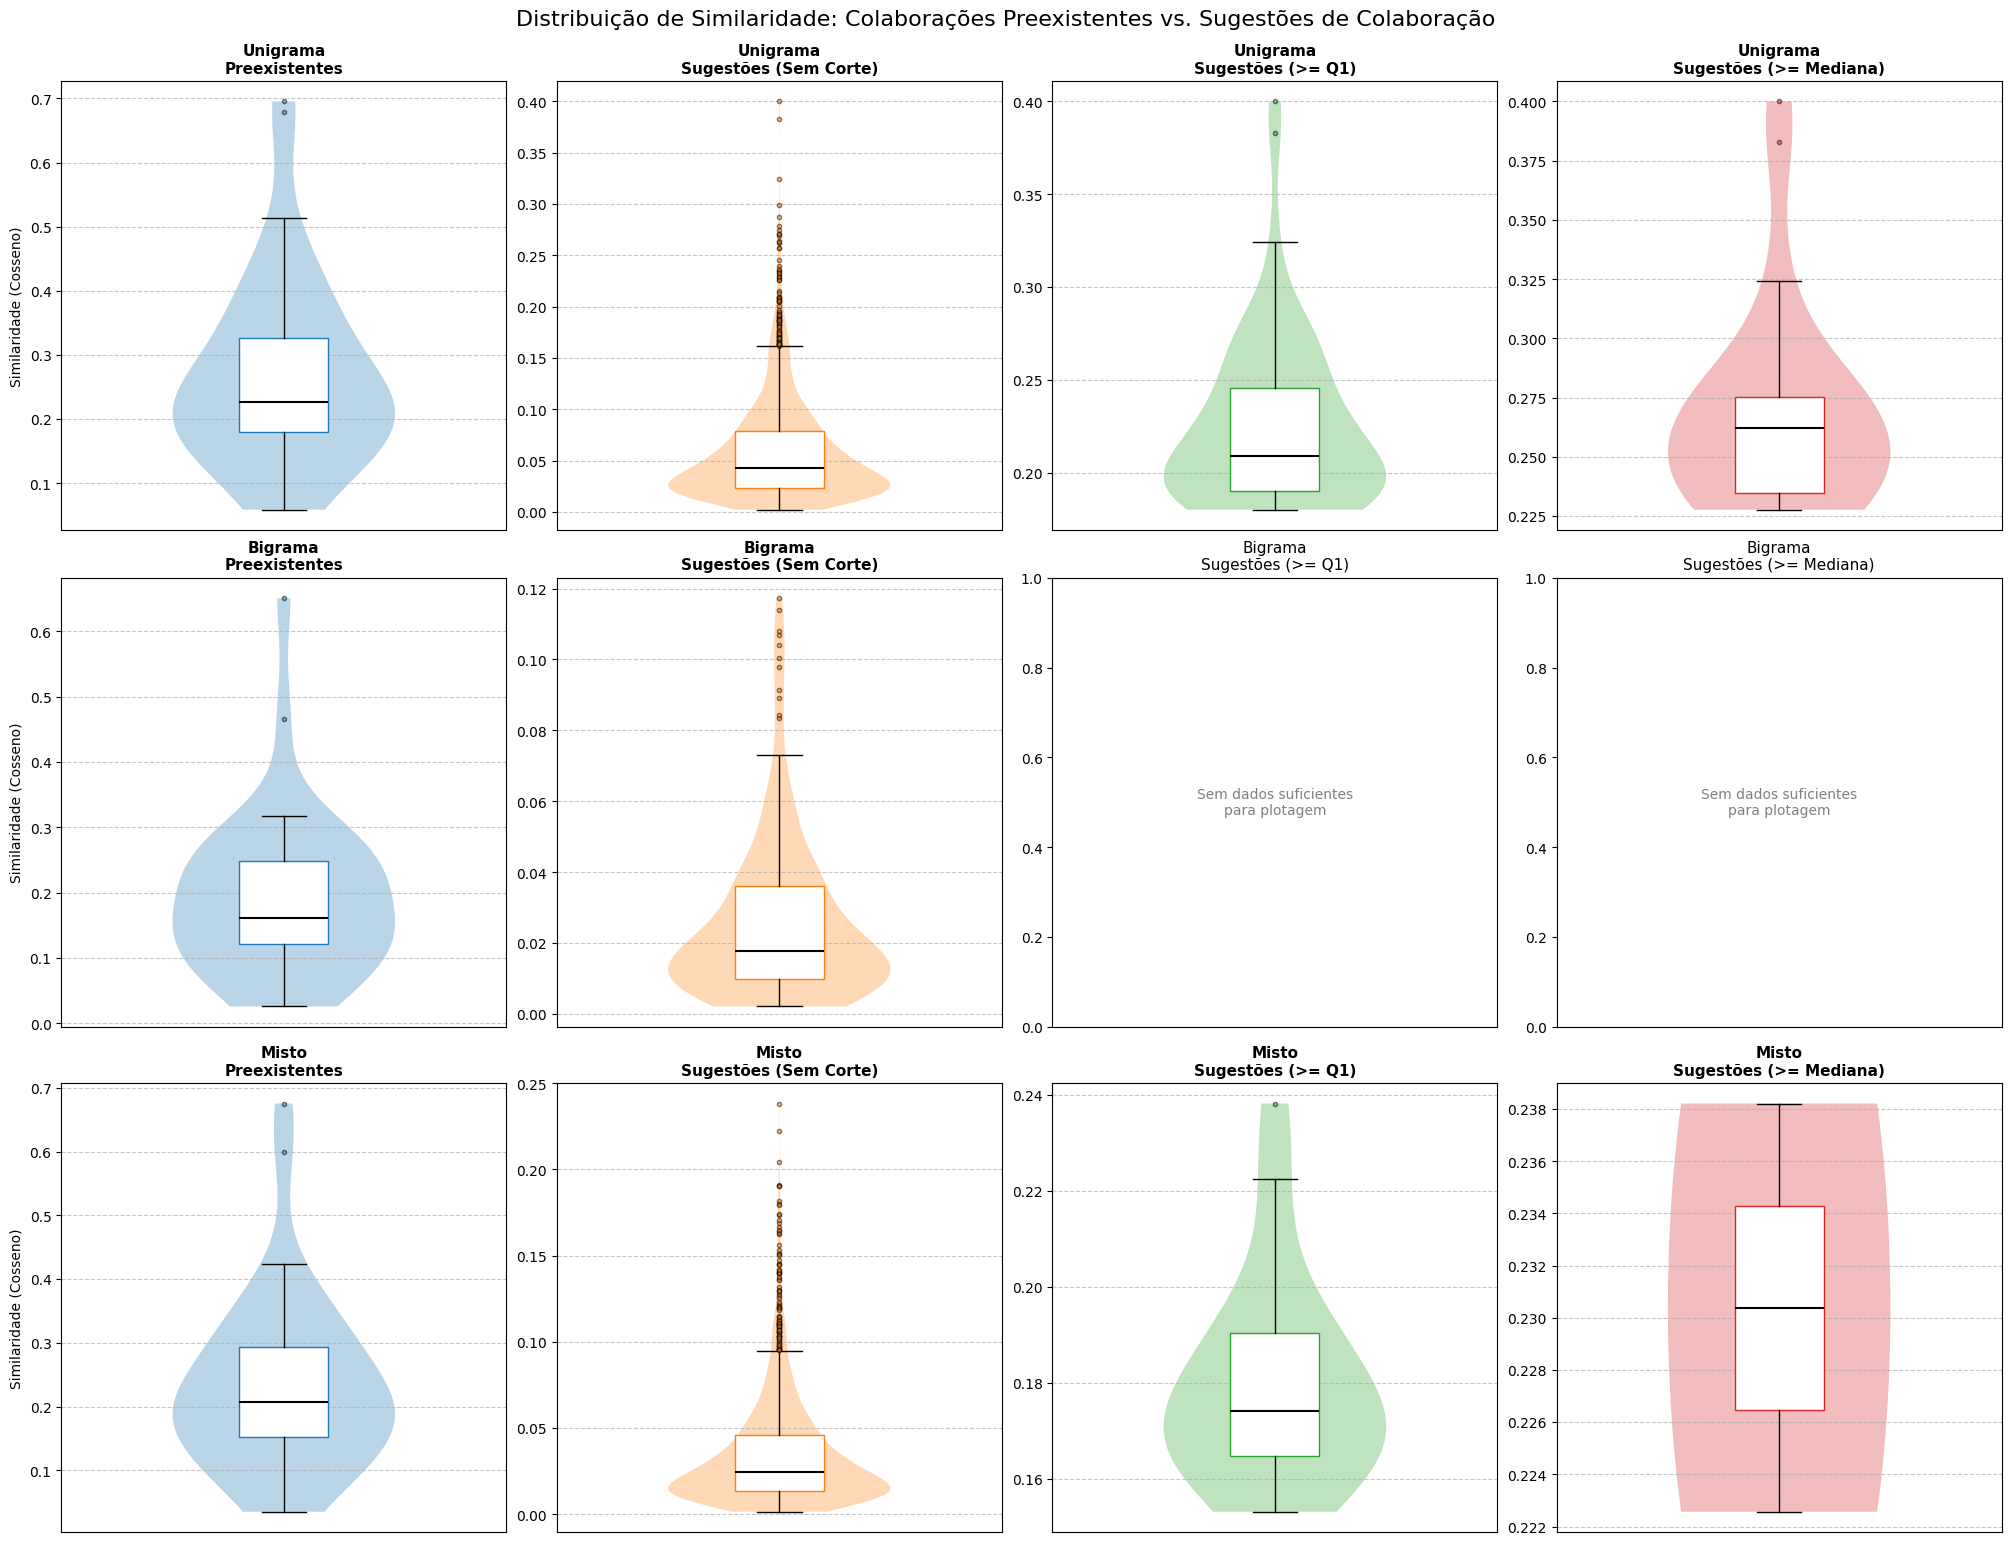

In [9]:
# ==============================================================================
# 9. ANÁLISE VISUAL DE DISTRIBUIÇÃO E DISPERSÃO
# ==============================================================================
print(">>> Gerando análise visual (Violin + Boxplot)... Isso pode levar alguns instantes.")

# 1. Configurações globais de estilo e paleta de cores
FIG_SIZE = (20, 15)
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Azul, laranja, verde, vermelho

scenarios_names = list(graph_data.keys())
type_names = ['Preexistentes', 'Sugestões (Sem Corte)', 'Sugestões (>= Q1)', 'Sugestões (>= Mediana)']

# 2. Inicialização do grid de subplots
fig, axes = plt.subplots(len(scenarios_names), len(type_names), figsize=FIG_SIZE, constrained_layout=True)

# 3. Loop de renderização iterativa: linha (cenário) x coluna (tipo de corte)
for i, scenario in enumerate(scenarios_names):
    for j, type_name in enumerate(type_names):
        
        ax = axes[i, j]
        data = graph_data[scenario][type_name]
        current_color = PALETTE[j]

        label = SCENARIO_LABELS[scenario]

        # Tratamento de edge cases: evita erro caso o filtro retorne vazio
        if len(data) == 0:
            ax.text(0.5, 0.5, 'Sem dados suficientes\npara plotagem', 
                   ha='center', va='center', fontsize=10, color='gray')
            ax.set_title(f"{label}\n{type_name}", fontsize=11) # <-- Usando o label traduzido
            ax.set_xticks([])
            continue

        # --- Camada 1: Violinplot (Densidade) ---
        # Removemos barras de média/mediana do violino para não poluir o boxplot
        parts = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
        
        # Estilização do corpo do violino
        for pc in parts['bodies']:
            pc.set_facecolor(current_color)
            pc.set_alpha(0.3) # Transparência para dar destaque ao boxplot

        # --- Camada 2: Boxplot (Estatística) ---
        # Sobrepomos o boxplot para marcar Q1, Mediana e Q3 com precisão
        ax.boxplot(data, widths=0.2, patch_artist=True,
                   boxprops=dict(facecolor="white", color=current_color),
                   medianprops=dict(color="black", linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor=current_color, markersize=3, alpha=0.5))

        # Cosmética do gráfico
        ax.set_title(f"{label}\n{type_name}", fontsize=11, fontweight='bold')
        ax.set_xticks([]) # Remove eixo X (redundante com o título)
        
        # Label apenas na primeira coluna para limpar o visual
        if j == 0:
            ax.set_ylabel("Similaridade (Cosseno)", fontsize=10)
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Título global e exportação do gráfico
fig.suptitle("Distribuição de Similaridade: Colaborações Preexistentes vs. Sugestões de Colaboração", fontsize=16, y=1.02)

plt.savefig('../assets/img/similarity_distribution_violin.png', dpi=300, bbox_inches='tight', facecolor='white')

print("✅ Gráfico gerado e salvo com sucesso!\n")
plt.show()

Conclusão Final

Com base na análise estatística e visual realizada, observamos que:

1.  O cenário de **unigrama** com corte na **mediana** apresentou a distribuição mais próxima das colaborações reais (menor *d* de Cohen e sobreposição visual no Violin Plot).
2.  As sugestões filtradas pela mediana eliminam o ruído de conexões fracas, mantendo apenas pares com similaridade semântica relevante.

# Geração da matriz filtrada de sugestões (para uso futuro)

In [10]:
# ==============================================================================
# 10. GERAÇÃO DA MATRIZ FILTRADA DE SUGESTÕES (MELHOR MODELO)
# ==============================================================================

# 1. Definição do cenário ótimo validado estatisticamente
BEST_SCENARIO = 'unigram'

# Cria uma cópia explícita para segurança
df_best_model = dfs[BEST_SCENARIO].copy()

# 2. Filtragem e penalização de pares preexistentes
# Cria uma matriz de condição para filtrar pares que já colaboraram (na matriz
# de adjacência, > 0) e substitui as similaridades de tais pares por -99
condition_matrix = (matrix_adj > 0)
df_best_model = df_best_model.mask(condition_matrix, -99.0)

# 3. Visualização da matriz final e de suas dimensões
print("Esta matriz possui -99 nas colaborações preexistentes.")
print(f"Dimensões: {df_best_model.shape}")
df_best_model

Esta matriz possui -99 nas colaborações preexistentes.
Dimensões: (89, 89)


,Adriano Jose Ferruzzi,Alessandra da Silva Carneiro,Alessandro Emilio Teruzzi,Alex Sandro Rodrigues Ancioto,Alexandre José Romagnoli,Alexandre Machado Rosa,Ana Carolina Vila Ramos dos Santos,Ana Claudia Folha da Cruz,Ana Márcia Lima Costa,Ana Paula Rodrigues Magalhães de Barros,...,Silene Jucelino de Lima,Tatiana Aparecida Picosque,Teresa Helena Buscato Martins,Thiago Pedro Donadon Homem,Thiago Silva Broze,Valdir Donizete dos Santos Junior,Vanessa Regina Ferreira da Silva,Whisner Fraga Mamede,Wilian Ramalho Feitosa,William Rosseti
Adriano Jose Ferruzzi,1.000000,0.0,0.000000,0.036120,0.047782,0.000000,0.026851,0.056773,0.000000,0.008676,...,0.000000,0.028387,0.064923,0.027418,0.033787,0.014517,0.000000,0.0,0.063665,0.022630
Alessandra da Silva Carneiro,0.000000,1.0,0.000000,0.000000,0.000000,0.052705,0.015610,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
Alessandro Emilio Teruzzi,0.000000,0.0,1.000000,0.048795,0.032275,0.000000,0.000000,0.000000,0.163299,0.117202,...,0.000000,0.000000,0.043853,0.000000,0.000000,0.039223,0.000000,0.0,0.009556,0.030571
Alex Sandro Rodrigues Ancioto,0.036120,0.0,0.048795,1.000000,0.031497,0.000000,0.000000,0.037424,0.039841,0.057189,...,0.000000,0.000000,0.064194,0.036147,0.000000,0.000000,0.000000,0.0,0.018652,0.014917
Alexandre José Romagnoli,0.047782,0.0,0.032275,0.031497,1.000000,0.052705,0.039024,0.049507,0.026352,0.007565,...,0.000000,0.024754,0.070767,0.000000,0.036828,0.012659,0.000000,0.0,0.101782,0.078934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valdir Donizete dos Santos Junior,0.014517,0.0,0.039223,0.000000,0.012659,0.032026,0.000000,0.000000,0.000000,0.027582,...,0.000000,0.000000,0.017201,0.019371,0.000000,1.000000,0.000000,0.0,0.003748,0.035973
Vanessa Regina Ferreira da Silva,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110096,0.173838,...,0.000000,0.000000,0.000000,0.000000,0.015386,0.000000,1.000000,0.0,0.019329,0.041222
Whisner Fraga Mamede,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.029463,0.000000,0.000000,1.0,0.000000,0.000000
Wilian Ramalho Feitosa,0.063665,0.0,0.009556,0.018652,0.101782,0.046816,0.048530,0.014659,0.015605,0.022400,...,-99.000000,0.029318,0.037717,0.089672,0.161389,0.003748,0.019329,0.0,1.000000,-99.000000


## Exportação

In [11]:
# ==============================================================================
# 11. EXPORTAÇÃO DOS DADOS DO MELHOR MODELO (LOAD)
# ==============================================================================
print(">>> Exportando matriz filtrada de sugestões...")

# 1. Salva matriz filtrada em Parquet
df_best_model.to_parquet(OUTPUT_FILTERED_MATRIX_PARQUET)
print(f"✅ Matriz salva com sucesso como: {OUTPUT_FILTERED_MATRIX_PARQUET}\n")

>>> Exportando matriz filtrada de sugestões...
✅ Matriz salva com sucesso como: ../data/processed/similarity_matrices/suggestions_filtered.parquet



In [12]:
# ==============================================================================
# 12. ROTINAS DE AUDITORIA OPCIONAIS
# ==============================================================================

# 1. Exportação alternativa para verificação manual em Excel (descomentar se necessário)
# df_best_model.to_csv(OUTPUT_FILTERED_MATRIX_CSV, sep=';', decimal=',', encoding='utf-8-sig', index=True)
# print(f'Matriz filtrada de sugestões salva com sucesso como {OUTPUT_FILTERED_MATRIX_CSV}')

# Exportação da matriz de colaborações preexistentes rotulada

In [13]:
# ==============================================================================
# 13. EXPORTAÇÃO DA MATRIZ DE COLABORAÇÕES PREEXISTENTES ROTULADA
# ==============================================================================
print(">>> Exportando matriz de colaborações preexistentes rotulada...")

# 1. Salva matriz rotulada em Parquet para as próximas etapas
matrix_adj.to_parquet(OUTPUT_LABELED_MATRIX_PARQUET)
print(f"✅ Matriz salva com sucesso como: {OUTPUT_LABELED_MATRIX_PARQUET}\n")

>>> Exportando matriz de colaborações preexistentes rotulada...
✅ Matriz salva com sucesso como: ../data/processed/pre_existing_labeled.parquet



In [14]:
# ==============================================================================
# 14. ROTINAS DE AUDITORIA OPCIONAIS
# ==============================================================================

# 1. Exportação alternativa para verificação manual em Excel (descomentar se necessário)
# matrix_adj.to_csv(OUTPUT_LABELED_MATRIX_CSV, sep=';', decimal=',', encoding='utf-8-sig', index=True)
# print(f'Matriz de colaborações preexistentes rotulada salva com sucesso como {OUTPUT_LABELED_MATRIX_CSV}')